### Goal: 
Co-cluster the excitatory with the dissorg cells

In [11]:
import numpy as np
import os
import sklearn.preprocessing
from umap import umap_ as umap
import wavemap_paper
%matplotlib widget
import matplotlib.pyplot as plt 
from matplotlib import cm
from matplotlib import pyplot as plt
import random
from wavemap_paper.helper_functions import RAND_STATE, set_rand_state, plot_inverse_mapping
import networkx as nx
import cylouvain
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import mplcursors


# get working directory
os.getcwd()

'd:\\MasterThesis\\code'

In [12]:
# Load the data
data_path_excit = "d:\\MasterThesis\\mean_waveforms_preprocessed_excit.csv"
data_path_dissorg = "d:\\MasterThesis\\mean_waveforms_preprocessed_dissorg.csv"

normWF_dissorg = np.loadtxt(data_path_dissorg, delimiter=',', dtype=float)
normWF_excit = np.loadtxt(data_path_excit, delimiter=',', dtype=float)

# Combine the datasets
all_wf = np.vstack([normWF_dissorg, normWF_excit])

# Keep track of origin
dataset_labels = (['dissorg'] * len(normWF_dissorg) + ['excit'] * len(normWF_excit))


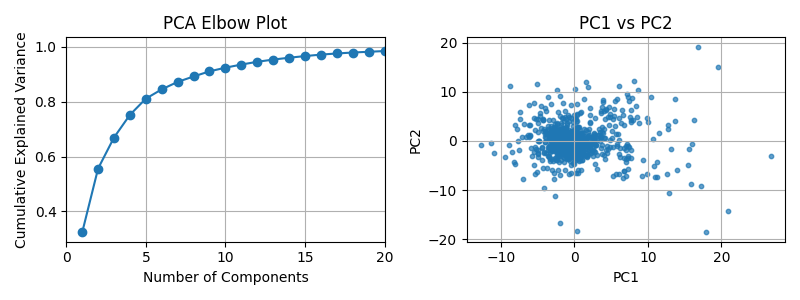

In [13]:
# Set seed
seed = 43
np.random.seed(seed)    # NumPy
random.seed(seed)       # Python built-in random module
set_rand_state(RAND_STATE)

# PCA here for dim reduction before UMAP
scaler = StandardScaler()
X_scaled = scaler.fit_transform(all_wf)
pca = PCA()
pca.fit(X_scaled)

explained_variance = pca.explained_variance_ratio_   # Explained variance ratio
cumulative_variance = np.cumsum(explained_variance)   # Cumulative explained variance

# Transform data into PCA space
X_pca = pca.transform(X_scaled)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

# Elbow plot
axes[0].plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker='o'
)

axes[0].set_xlabel('Number of Components')
axes[0].set_ylabel('Cumulative Explained Variance')
axes[0].set_title('PCA Elbow Plot')
axes[0].set_xlim((0, 20))
axes[0].grid(True)

# PC1 vs PC2
axes[1].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    s=10,
    alpha=0.7
)

axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('PC1 vs PC2')
axes[1].grid(True)

plt.tight_layout()
plt.show()

maybe change colour here too

In [ ]:
####### UMAP dimensionality reduction  ########

n_comps = 2

reducer = umap.UMAP(random_state=RAND_STATE, n_neighbors=10, n_components=n_comps)
mapper = reducer.fit(all_wf)
G = nx.from_scipy_sparse_array(mapper.graph_)
clustering = cylouvain.best_partition(G,resolution=3)
clustering_solution = list(clustering.values())

embedding = reducer.fit_transform(all_wf)

# automatic column names
col_names = [f'umap_{i+1}' for i in range(n_comps)]

umap_df = pd.DataFrame(embedding,columns=col_names)
umap_df['waveform'] = list(all_wf)
umap_df['cluster_id'] = clustering_solution
umap_df['dataset'] = dataset_labels


# colours
cmap = plt.get_cmap("turbo")
colors = cmap(np.linspace(0,1,len(set(clustering_solution))))
umap_df['cluster_color'] = [colors[i]for i in clustering_solution]

adjacency_matrix will return a scipy.sparse array instead of a matrix in Networkx 3.0.


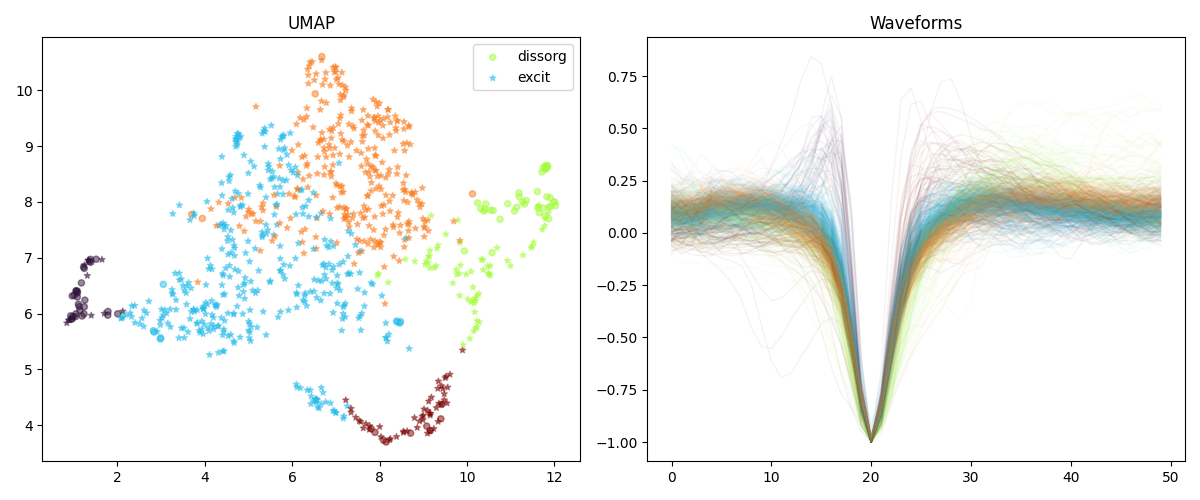

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# -------------------------
# 1) UMAP scatter
# -------------------------
marker_map = {'dissorg': 'o','excit': '*'}

for dataset, marker in marker_map.items():

    subset = umap_df[umap_df['dataset'] == dataset]

    axes[0].scatter(
        subset['umap_1'],
        subset['umap_2'],
        c=subset['cluster_id'],
        cmap='turbo',
        marker=marker,
        s=20,
        picker=True,
        label=dataset,
        alpha=0.5
    )
axes[0].legend()
axes[0].set_title("UMAP")

# -------------------------
# 2) Background waveforms
# -------------------------
for i, wf in enumerate(umap_df['waveform']):
    axes[1].plot(
        wf,
        color=umap_df['cluster_color'].iloc[i],
        alpha=0.05,
        linewidth=1
    )

axes[1].set_title("Waveforms")

# -------------------------
# Highlighted waveform
# -------------------------
highlight_line, = axes[1].plot(
    [],
    [],
    linewidth=3
)

# -------------------------
# CLICK interaction
# -------------------------
cursor = mplcursors.cursor([sc], hover=False)

@cursor.connect("add")
def on_click(sel):

    idx = sel.index
    wf = umap_df['waveform'].iloc[idx]

    # update highlighted waveform
    highlight_line.set_data(
        np.arange(len(wf)),
        wf
    )

    # match waveform color
    highlight_line.set_color(
        umap_df['cluster_color'].iloc[idx]
    )

    # rescale waveform axis if needed
    axes[1].relim()
    axes[1].autoscale_view()

    fig.canvas.draw_idle()

plt.tight_layout()
plt.show()

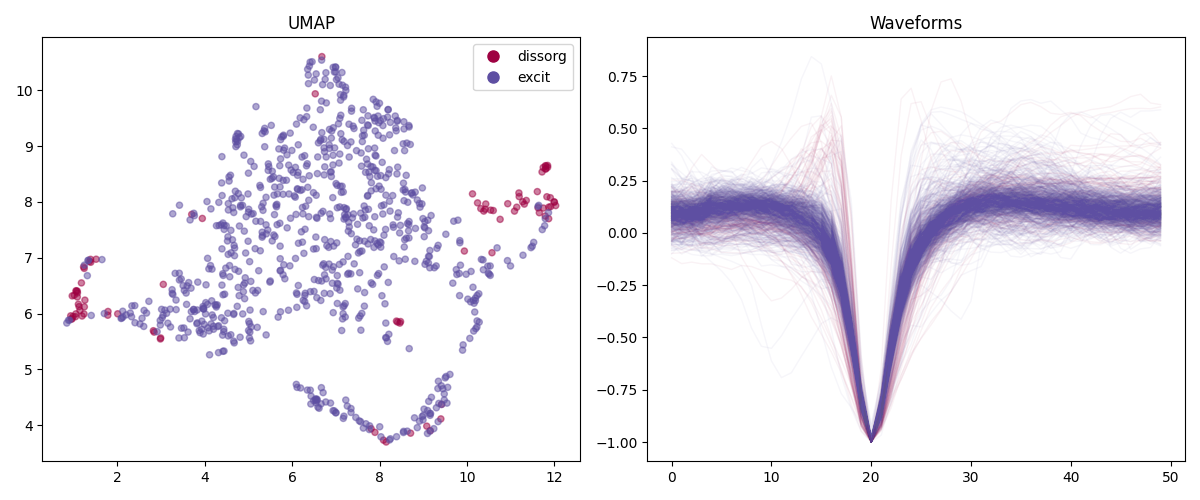

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
c_name = "Spectral"

# -------------------------
# 1) UMAP scatter
# -------------------------
dataset_map = {'dissorg': 0, 'excit': 1}

# scatter
sc = axes[0].scatter(
    umap_df['umap_1'],
    umap_df['umap_2'],
    c=umap_df['dataset'].map(dataset_map),
    cmap=c_name,
    s=20,
    alpha=0.5,
    picker=True
)

# get actual colors from colormap
cmap = plt.get_cmap(c_name)

dataset_colors = {name: cmap(val / (len(dataset_map)-1)) for name, val in dataset_map.items()}

# matching legend
handles = [plt.Line2D([],[],marker='o',linestyle='',color=dataset_colors[name],label=name,markersize=8)
    for name in dataset_map]

axes[0].legend(handles=handles)

axes[0].set_title("UMAP")

# -------------------------
# 2) Background waveforms
# -------------------------
for i, wf in enumerate(umap_df['waveform']):
    axes[1].plot(
        wf,
        color=dataset_colors[umap_df['dataset'].iloc[i]],
        alpha=0.05,
        linewidth=1
    )

axes[1].set_title("Waveforms")

# -------------------------
# Highlighted waveform
# -------------------------
highlight_line, = axes[1].plot(
    [],
    [],
    linewidth=3
)

# -------------------------
# CLICK interaction
# -------------------------
cursor = mplcursors.cursor([sc], hover=False)

@cursor.connect("add")
def on_click(sel):

    idx = sel.index
    wf = umap_df['waveform'].iloc[idx]

    # update highlighted waveform
    highlight_line.set_data(
        np.arange(len(wf)),
        wf
    )

    # match waveform color
    highlight_line.set_color(
        dataset_colors[umap_df['dataset'].iloc[idx]]
    )

    # rescale waveform axis if needed
    axes[1].relim()
    axes[1].autoscale_view()

    fig.canvas.draw_idle()

plt.tight_layout()
plt.show()

it may be a problem that the datasets are so imbalanced, maybe could try sampling significanty?

In [54]:
# select random subset of excitatory waves
n_dissorg = len(normWF_dissorg)

np.random.seed(43)

excit_idx = np.random.choice(len(normWF_excit),size=n_dissorg,replace=False)
normWF_excit_sub = normWF_excit[excit_idx]

all_wf_corr = np.vstack([normWF_dissorg,normWF_excit_sub])            # corrected for 

dataset_labels = (['dissorg'] * len(normWF_dissorg) +['excit'] * len(normWF_excit_sub))

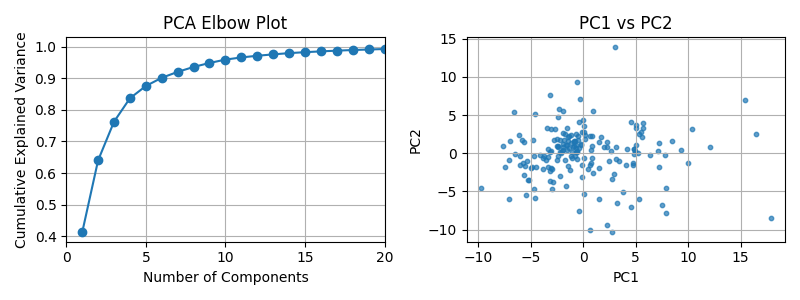

In [55]:
# Set seed
seed = 43
np.random.seed(seed)    # NumPy
random.seed(seed)       # Python built-in random module
set_rand_state(RAND_STATE)

# PCA here for dim reduction before UMAP
scaler = StandardScaler()
X_scaled = scaler.fit_transform(all_wf_corr)
pca = PCA()
pca.fit(X_scaled)

explained_variance = pca.explained_variance_ratio_   # Explained variance ratio
cumulative_variance = np.cumsum(explained_variance)   # Cumulative explained variance

# Transform data into PCA space
X_pca = pca.transform(X_scaled)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

# Elbow plot
axes[0].plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker='o'
)

axes[0].set_xlabel('Number of Components')
axes[0].set_ylabel('Cumulative Explained Variance')
axes[0].set_title('PCA Elbow Plot')
axes[0].set_xlim((0, 20))
axes[0].grid(True)

# PC1 vs PC2
axes[1].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    s=10,
    alpha=0.7
)

axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('PC1 vs PC2')
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [56]:
####### UMAP dimensionality reduction  ########

n_comps = 3

reducer = umap.UMAP(random_state=RAND_STATE, n_neighbors=15, n_components=n_comps)
mapper = reducer.fit(all_wf_corr)
G = nx.from_scipy_sparse_array(mapper.graph_)
clustering = cylouvain.best_partition(G,resolution=3)
clustering_solution = list(clustering.values())

embedding = reducer.fit_transform(all_wf_corr)

# automatic column names
col_names = [f'umap_{i+1}' for i in range(n_comps)]

umap_df = pd.DataFrame(embedding,columns=col_names)
umap_df['waveform'] = list(all_wf_corr)
umap_df['cluster_id'] = clustering_solution
umap_df['dataset'] = dataset_labels

# colours
cmap = plt.get_cmap("turbo")
colors = cmap(np.linspace(0,1,len(set(clustering_solution))))
umap_df['cluster_color'] = [colors[i]for i in clustering_solution]

adjacency_matrix will return a scipy.sparse array instead of a matrix in Networkx 3.0.


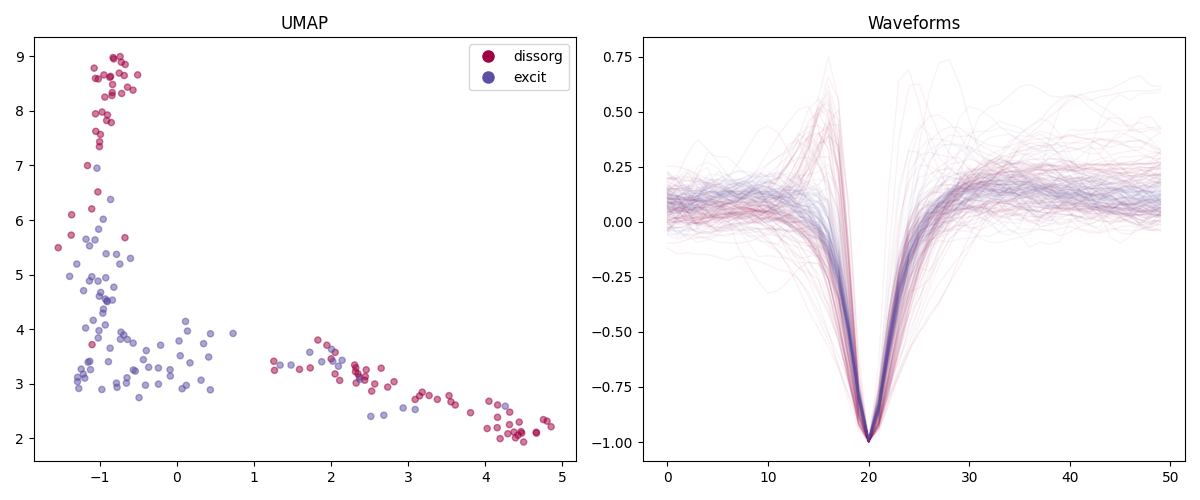

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
c_name = "Spectral"

# -------------------------
# 1) UMAP scatter
# -------------------------
dataset_map = {'dissorg': 0, 'excit': 1}

# scatter
sc = axes[0].scatter(
    umap_df['umap_1'],
    umap_df['umap_2'],
    c=umap_df['dataset'].map(dataset_map),
    cmap=c_name,
    s=20,
    alpha=0.5,
    picker=True
)

# get actual colors from colormap
cmap = plt.get_cmap(c_name)

dataset_colors = {name: cmap(val / (len(dataset_map)-1)) for name, val in dataset_map.items()}

# matching legend
handles = [plt.Line2D([],[],marker='o',linestyle='',color=dataset_colors[name],label=name,markersize=8)
    for name in dataset_map]

axes[0].legend(handles=handles)

axes[0].set_title("UMAP")

# -------------------------
# 2) Background waveforms
# -------------------------
for i, wf in enumerate(umap_df['waveform']):
    axes[1].plot(
        wf,
        color=dataset_colors[umap_df['dataset'].iloc[i]],
        alpha=0.05,
        linewidth=1
    )

axes[1].set_title("Waveforms")

# -------------------------
# Highlighted waveform
# -------------------------
highlight_line, = axes[1].plot(
    [],
    [],
    linewidth=3
)

# -------------------------
# CLICK interaction
# -------------------------
cursor = mplcursors.cursor([sc], hover=False)

@cursor.connect("add")
def on_click(sel):

    idx = sel.index
    wf = umap_df['waveform'].iloc[idx]

    # update highlighted waveform
    highlight_line.set_data(
        np.arange(len(wf)),
        wf
    )

    # match waveform color
    highlight_line.set_color(
        dataset_colors[umap_df['dataset'].iloc[idx]]
    )

    # rescale waveform axis if needed
    axes[1].relim()
    axes[1].autoscale_view()

    fig.canvas.draw_idle()

plt.tight_layout()
plt.show()

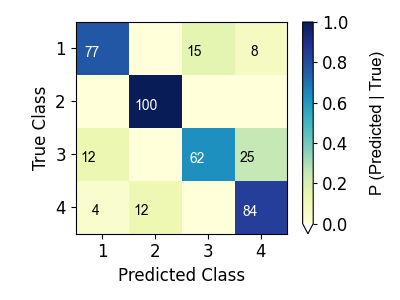

In [52]:
# do the wavemap interpretable machine learning stuff

from wavemap_paper.helper_functions import train_gridsearch_classifier, plot_confusion_matrix 
umap_model, conf_mat = train_gridsearch_classifier(umap_df)

plot_confusion_matrix(conf_mat,umap_df)


In [49]:
import shap 
import xgboost as xgb 
xgbModel = xgb.XGBClassifier(umap_model.best_params_) 
xgbModel.fit(umap_df['waveform'].tolist(),umap_df['cluster_id'].tolist()) 
explainer = shap.TreeExplainer(xgbModel)

Pass `objective` as keyword args.


ntree_limit is deprecated, use `iteration_range` or model slicing instead.


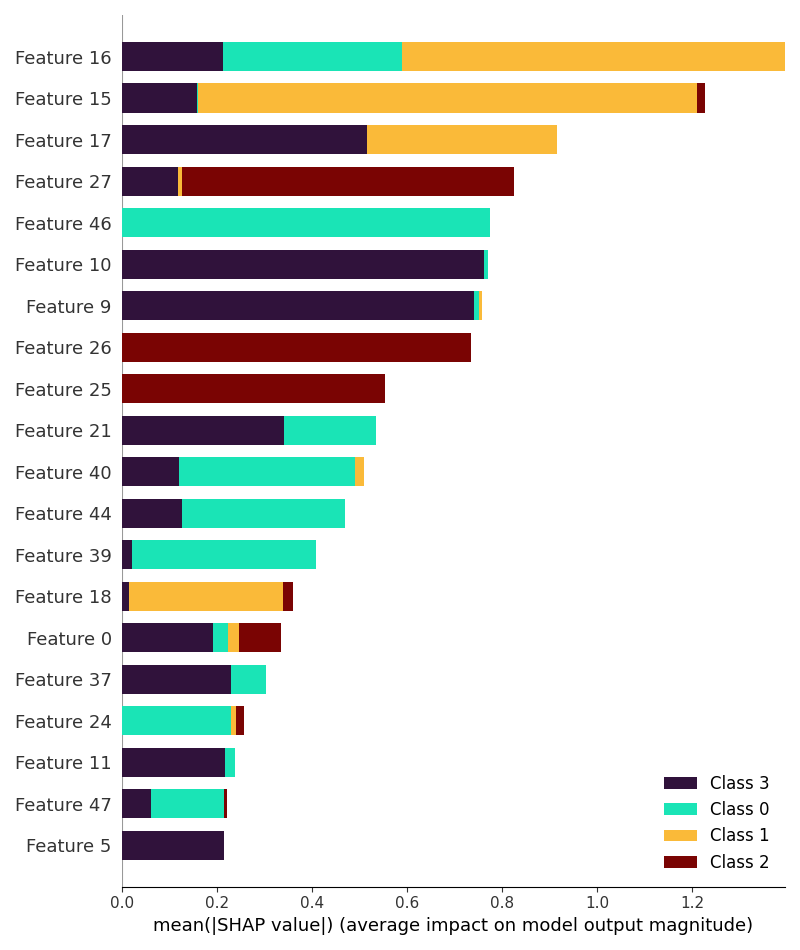

In [53]:
import matplotlib as mpl 
plt.close('all')
umap_cmap = mpl.colors.ListedColormap(colors, name='umap_cmap') 
shap_values = explainer.shap_values(umap_df['waveform'].tolist()) 
shap.summary_plot(shap_values, color = umap_cmap)